In [ ]:
!git clone -q https://github.com/Mikayla-ds2/surge-sense.git

In [ ]:
%cd surge-sense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

%pip install pmdarima
import pmdarima as pm

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/daily_visits.csv')

In [ ]:
data.head()

In [ ]:
data.info()

In [ ]:
data['admission_day'] = pd.to_datetime(data['admission_day'])

In [ ]:
plot = data.plot(x='admission_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('# of Visits')
plt.xlabel('Time')
plt.ylabel('# of Visits')
plt.show()

In [ ]:
data['month_day'] = data['admission_day'].dt.strftime('%m-%d')
data.head()

In [ ]:
data['month'] = data['admission_day'].dt.strftime('%m')
data['day'] = data['admission_day'].dt.strftime('%d')
data.head()

In [ ]:
sum_visits = data.groupby('month_day', as_index=False)['visit_count'].sum()
agg_visits_sum = sum_visits.sort_values('month_day')

display(agg_visits_sum.loc[agg_visits_sum['visit_count'].nlargest(10).index])

plot = agg_visits_sum.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Total Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Total Visit Count')
plt.show()

In [ ]:
avg_visits = data.groupby('month_day', as_index=False)['visit_count'].mean()
agg_visits_avg = avg_visits.sort_values('month_day')

display(agg_visits_avg.loc[agg_visits_avg['visit_count'].nlargest(10).index])

plot = agg_visits_avg.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Average Visit Count')
plt.show()

,month,visit_count
1,02,14.862069
6,07,15.354839
10,11,15.466667
8,09,15.583333
11,12,15.774194
3,04,15.800000
9,10,15.803279
4,05,16.112903
2,03,16.322581
7,08,16.516129


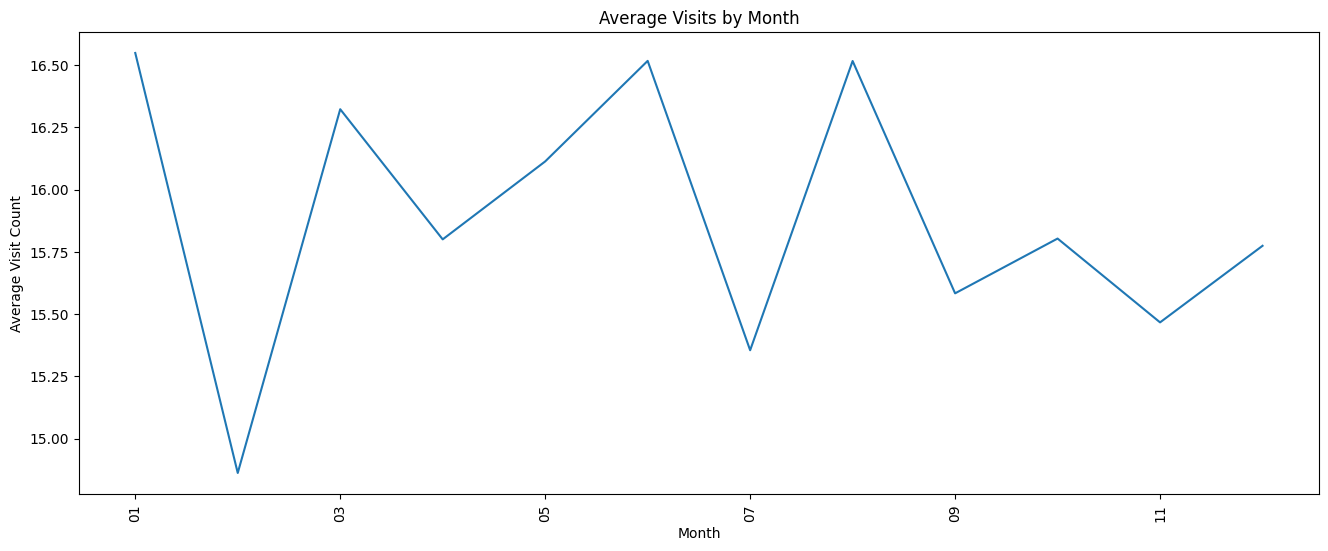

In [30]:
monthly_avg_visits = data.groupby('month', as_index=False)['visit_count'].mean()
agg_monthly_avg_visits = monthly_avg_visits.sort_values('month')

display(agg_monthly_avg_visits.loc[agg_monthly_avg_visits['visit_count'].nsmallest(12).index])

plot = agg_monthly_avg_visits.plot(x='month', y='visit_count', legend=False, figsize=(16, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Month')
plt.xlabel('Month')
plt.ylabel('Average Visit Count')
plt.show()

In [ ]:
data['quarter'] = pd.PeriodIndex(data.admission_day, freq='Q')
data.head()

,quarter,visit_count
4,2024Q2,16.186813
5,2024Q3,16.130435
0,2023Q2,16.098901
3,2024Q1,15.934066
2,2023Q4,15.717391
6,2024Q4,15.700000
1,2023Q3,15.510870


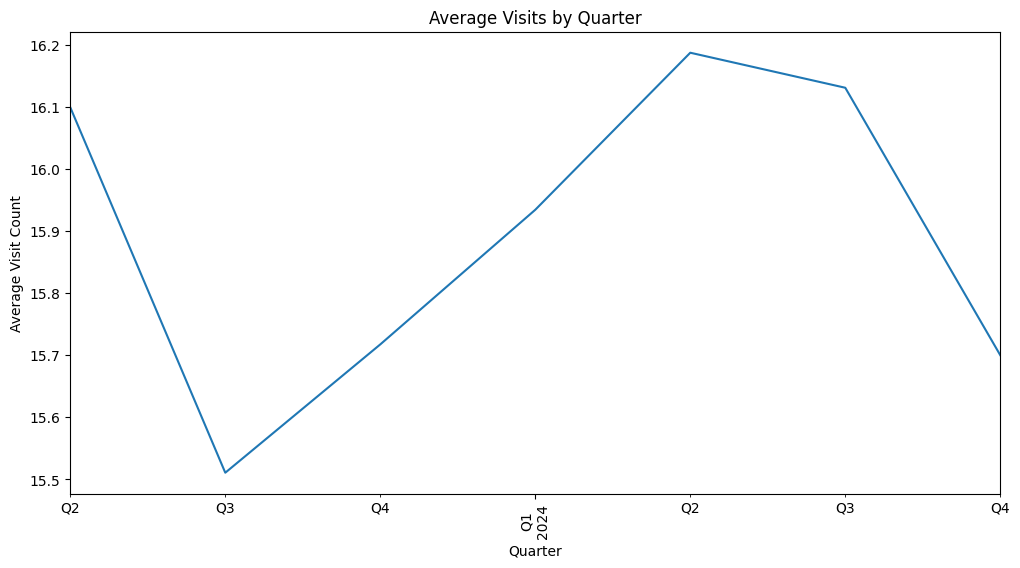

In [31]:
quarterly_avg_visits = data.groupby('quarter', as_index=False)['visit_count'].mean()
agg_visits = quarterly_avg_visits.sort_values('quarter')

display(agg_visits.loc[agg_visits['visit_count'].nlargest(10).index])    

plot = agg_visits.plot(x='quarter', y='visit_count', legend=False, figsize=(12, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Visit Count')
plt.show()

In [32]:
data.visit_count.describe()

,visit_count
count,579.000000
mean,15.917098
std,3.726836
min,7.000000
25%,13.000000
50%,16.000000
75%,18.000000
max,30.000000


Detected 25 outliers (4.32% of the dataset) visit_count column using z-scores.



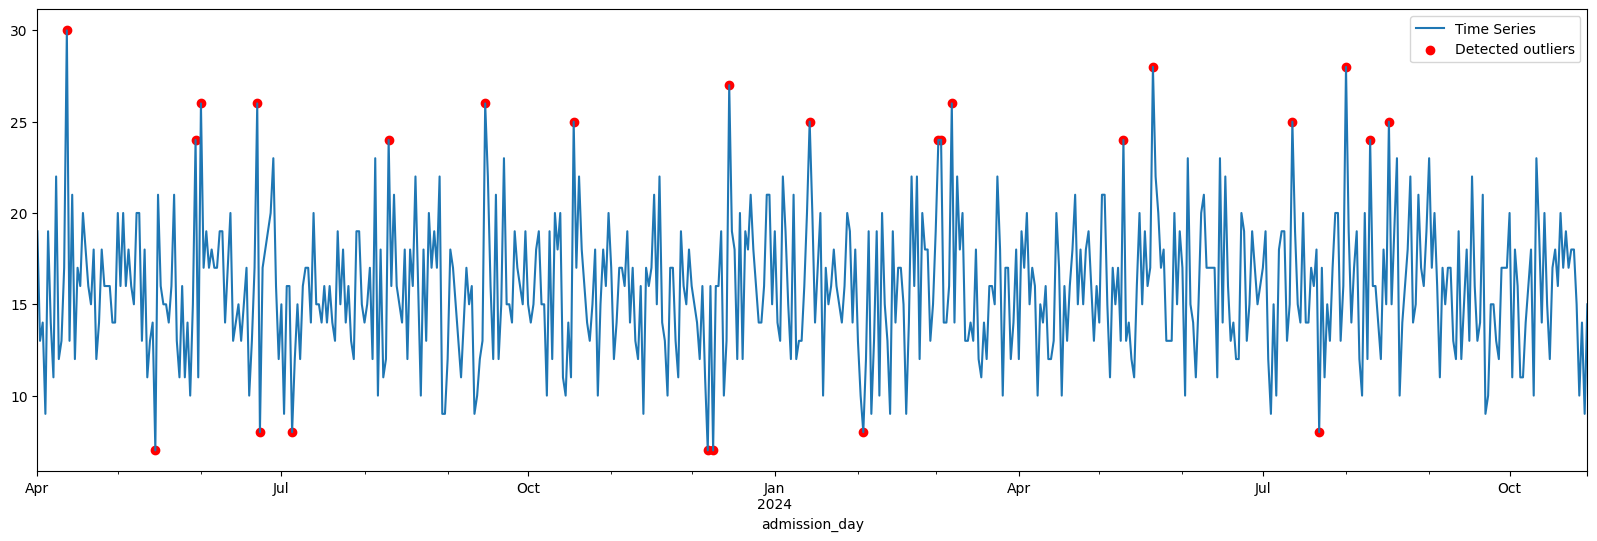

In [37]:
# outlier detection
df = data.copy()
df['z_score'] = np.abs((df['visit_count'] - df['visit_count'].mean()) / df['visit_count'].std())
outliers_z_score = df[df['z_score'] > 2]
z_outlier_percent = (len(outliers_z_score) / len(df)) * 100

print(f"Detected {len(outliers_z_score)} outliers ({z_outlier_percent:.2f}% of the dataset) visit_count column using z-scores.\n")

ax = data.plot(x='admission_day', y='visit_count', label="Time Series", figsize=(20, 6))
outlier_dates = matplotlib.dates.date2num(outliers_z_score['admission_day'])
ax.scatter(outlier_dates, outliers_z_score['visit_count'], color='red', label='Detected outliers')
ax.legend()
plt.show()